# Operator factorization ablation: factorized vs joint latent map

The networked operator

$$
I \otimes K_{\mathrm{self}} + \hat{A} \otimes K_{\mathrm{nbr}}
$$

ties parameters across nodes. This notebook measures what that tying costs on a
small path-diffusion surrogate: rollout MSE, trainable (or fitted) parameter
count, and spectral agreement versus an **unconstrained** joint map on the same
flattened latents. Results are for $N=4$, $d=2$ only — do not generalize
beyond this setup.


## Setup


In [1]:
import warnings

from tqdm.std import TqdmExperimentalWarning, TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
import torch

import koopman_graph
from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel, compute_spectrum
from koopman_graph.analysis import dynamical_similarity
from koopman_graph.baselines.base import fit_row_operator
from koopman_graph.datasets.synthetic import SyntheticDynamicGraphBenchmark

SEED = 0
N = 4
FEATURES = 2
LATENT = 2  # joint state dim = N * LATENT = 8
STEPS = 8
EPOCHS = 80
LR = 5e-3
torch.manual_seed(SEED)

DIFFUSION = dict(
    in_channels=FEATURES,
    topology="path",
    diffusion_rate=0.35,
    decay_rate=0.92,
    noise_std=0.0,
    initial_state="ones",
)

print(
    f"koopman_graph {koopman_graph.__version__}; "
    f"torch {torch.__version__}; joint state dim = {N * LATENT}"
)


koopman_graph 0.10.0; torch 2.13.0; joint state dim = 8


## Motivation and background

Factorized graph Koopman operators keep two shared $d \times d$ blocks
($K_{\mathrm{self}}$, $K_{\mathrm{nbr}}$; $2d^2$ free parameters in the
default symmetric adjacency mode) and rebuild an effective
$(Nd) \times (Nd)$ map through the adjacency
([Li et al., 2020](https://openreview.net/forum?id=H1ldzA4tPr)). That is a
strong inductive bias: every node shares the same blocks, and coupling enters
only through $\hat{A}$.

An unconstrained joint operator on flattened latents has $(Nd)^2$ free entries
and can represent couplings the Kronecker form cannot. At small $N$ we can fit
that joint map by least squares on encoded trajectories and ask how much
multi-step accuracy and spectral structure the factorization leaves on the
table — without claiming the gap holds for large graphs or other systems.


## Minimal example: shared encoder/decoder, two latent maps

1. Train `koopman="graph"` end-to-end (factorized operator + GNN codec).
2. Freeze the codec; encode the training trajectory.
3. Fit an unrestricted $K_{\mathrm{joint}} \in \mathbb{R}^{Nd \times Nd}$ with
   `fit_row_operator` (row convention $z_{t+1} = z_t K^{\top}$).
4. Roll out both maps from the same holdout origin and decode with the same
   decoder.


In [2]:
train = SyntheticDynamicGraphBenchmark.generate(
    num_nodes=N, num_timesteps=50, seed=0, **DIFFUSION
)
hold = SyntheticDynamicGraphBenchmark.generate(
    num_nodes=N, num_timesteps=20, seed=1, **DIFFUSION
)
edge_index = train[0].edge_index

torch.manual_seed(SEED)
graph_model = GraphKoopmanModel(
    GNNEncoder(FEATURES, 32, LATENT, num_layers=2),
    GNNDecoder(LATENT, 32, FEATURES, num_layers=2),
    latent_dim=LATENT,
    time_step=1.0,
    koopman="graph",
)
_ = graph_model.fit(train, epochs=EPOCHS, lr=LR, device="cpu")
graph_model.eval()

with torch.no_grad():
    Z_train = torch.stack(
        [
            graph_model.encode_at(train, t).reshape(-1)
            for t in range(train.num_timesteps)
        ]
    )
K_joint = fit_row_operator(Z_train[:-1], Z_train[1:], rank=None)

print("K_joint shape:", tuple(K_joint.shape))
print(
    "factor params:",
    sum(p.numel() for p in graph_model.koopman.parameters() if p.requires_grad),
)
print("joint fitted entries:", int(K_joint.numel()))


K_joint shape: (8, 8)
factor params: 8
joint fitted entries: 64


## Progressive deep dive: rollout, counts, spectra

Parameter counts compare the **trainable** factorized blocks to the **fitted**
joint matrix (the joint arm is not end-to-end trained). Spectral agreement uses
`dynamical_similarity` between the factorized effective spectrum and
`compute_spectrum(K_joint)`.


In [3]:
def rollout_mse_graph(model, sequence, steps: int = STEPS) -> float:
    preds = model.predict(sequence[0], steps)
    errs = [
        torch.mean((preds[h].x - sequence[h + 1].x) ** 2) for h in range(steps)
    ]
    return float(torch.stack(errs).mean().item())


def rollout_mse_joint(model, K, sequence, steps: int = STEPS) -> float:
    with torch.no_grad():
        z = model.encode(sequence[0]).reshape(-1)
        errs = []
        for h in range(steps):
            z = z @ K.T
            x_hat = model.decoder(z.reshape(N, LATENT), edge_index, None)
            errs.append(torch.mean((x_hat - sequence[h + 1].x) ** 2))
    return float(torch.stack(errs).mean().item())


mse_factor = rollout_mse_graph(graph_model, hold)
mse_joint = rollout_mse_joint(graph_model, K_joint, hold)
n_factor = sum(
    p.numel() for p in graph_model.koopman.parameters() if p.requires_grad
)
n_joint = int(K_joint.numel())

spec_factor = graph_model.spectrum(edge_index=edge_index, num_nodes=N)
spec_joint = compute_spectrum(K_joint.detach(), graph_model.time_step)
spectrum_distance = float(dynamical_similarity(spec_factor, spec_joint).detach())

K_eff = graph_model.koopman.effective_matrix(edge_index, N)
print(f"factorized rollout MSE: {mse_factor:.4f}")
print(f"joint LS rollout MSE:   {mse_joint:.4f}")
print(f"parameter count:        factor={n_factor}  joint={n_joint}")
print(f"spectral distance:      {spectrum_distance:.4f}")
print(f"effective K shape:      {tuple(K_eff.shape)}")


factorized rollout MSE: 0.7075
joint LS rollout MSE:   0.0185
parameter count:        factor=8  joint=64
spectral distance:      0.5919
effective K shape:      (8, 8)


## Results

Bars: multi-step MSE (left) and operator degrees of freedom (right). Expect the
joint LS fit on frozen latents to achieve lower rollout error at an
$(Nd)^2 / (2d^2)$ parameter premium ($64/8 = 8\times$ here). Look for a
large left-bar gap together with the $8\times$ right-bar DoF ratio. The
printed spectral distance (default Wasserstein comparison via
`dynamical_similarity`) quantifies disagreement between the factorized
effective spectrum and the joint spectrum — not a claim about ResDMD
residuals.


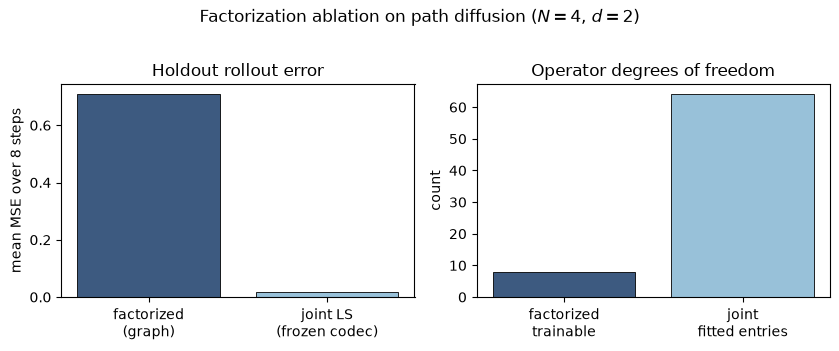

Measured ratio joint/factor MSE: 0.0261; param ratio joint/factor: 8.0; spectral distance: 0.5919


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.4))

axes[0].bar(
    ["factorized\n(graph)", "joint LS\n(frozen codec)"],
    [mse_factor, mse_joint],
    color=["#3d5a80", "#98c1d9"],
    edgecolor="black",
    linewidth=0.6,
)
axes[0].set_ylabel(f"mean MSE over {STEPS} steps")
axes[0].set_title("Holdout rollout error")

axes[1].bar(
    ["factorized\ntrainable", "joint\nfitted entries"],
    [n_factor, n_joint],
    color=["#3d5a80", "#98c1d9"],
    edgecolor="black",
    linewidth=0.6,
)
axes[1].set_ylabel("count")
axes[1].set_title("Operator degrees of freedom")
fig.suptitle(
    f"Factorization ablation on path diffusion ($N={N}$, $d={LATENT}$)",
    y=1.02,
)
fig.tight_layout()
plt.show()

print(
    f"Measured ratio joint/factor MSE: {mse_joint / max(mse_factor, 1e-12):.4f}; "
    f"param ratio joint/factor: {n_joint / n_factor:.1f}; "
    f"spectral distance: {spectrum_distance:.4f}"
)


## Interpretation / discussion

On this seeded path-diffusion surrogate with a shared GNN codec, unrestricted
least-squares on flattened latents substantially reduces multi-step MSE relative
to the trained factorized operator, at an $8\times$ increase in operator
degrees of freedom ($64$ vs $8$). Spectral distance between the effective
factorized operator and $K_{\mathrm{joint}}$ is nonzero, so the two maps are
not merely reparameterizations of each other.

Caveats: the joint arm is a **post-hoc** linear fit on frozen encodings, not a
second end-to-end trained model; the factorized arm carries whatever the
encoder–operator–decoder training achieved in $80$ epochs. The comparison
therefore measures expressiveness *available in the latent coordinates the
factorized model learned*, not a fully optimized joint neural baseline. Do not
extrapolate the numerical gap to larger $N$, other topologies, or systems
where the Kronecker structure matches the physics.


## Takeaways

- Factorization buys a $2d^2$ operator budget and topology-conditioned
  advance; the unconstrained latent map needs $(Nd)^2$ entries.
- On this $N=4$, $d=2$ diffusion surrogate, joint LS on frozen latents
  achieved much lower holdout MSE than the trained factorized operator, with
  nontrivial spectral distance between the two maps.
- Report both error **and** parameter count; a lower joint error alone is not a
  reason to abandon factorization when $N$ is large.
- Rebuild or refute this ablation before claiming the factorized form is
  "essentially as expressive" on a new domain.


## Further reading

- Package API: `GraphKoopmanOperator.effective_matrix`, `GraphKoopmanModel`
  with `koopman="graph"`, `fit_row_operator`, `compute_spectrum`,
  `dynamical_similarity`
- Related notebooks: `37_cross_topology_transfer.ipynb` (cross-$N$ transfer),
  `35_symmetry_adapted_operator.ipynb` (orbit ties),
  `29_scalable_operators.ipynb` ($N \cdot d$ cost)
- Li, Y., He, H., Wu, J., Katabi, D., & Torralba, A. (2020). Learning
  compositional Koopman operators for model-based control.
  *International Conference on Learning Representations (ICLR)*.
  https://openreview.net/forum?id=H1ldzA4tPr
